# Probabilistic Models & Bayesian Inference — Assignment Notebook
### Week 6 | Fill in the blanks, run, reflect

---

**Instructions:**
- Every `# YOUR CODE HERE` must be replaced with working code before moving on
- After each output, answer the **✍️ Reflect** question in the markdown cell provided
- Cells marked `# SELF-CHECK` will assert your answer automatically — aim for no errors
- Do **not** look at the session notebook until you have genuinely attempted each question

> **Mindset:** The blanks are not syntax tests. Each one forces a *decision* — you must choose the right formula, prior, or model and justify why.

> **Datasets:**
> - **Telco Customer Churn** (Parts 1–4, 6): same CSV from Week 5
> - **Mauna Loa CO₂** (Part 5 only): `from statsmodels.datasets import co2` — 3 lines to load

---


In [ ]:
!pip install -q pymc arviz pgmpy scikit-learn scipy statsmodels pandas numpy matplotlib seaborn

In [1]:
# Run this cell first — all imports and data loading happen here
import warnings

warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import beta as beta_dist, dirichlet

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ExpSineSquared,
    WhiteKernel,
    DotProduct,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pymc as pm
import arviz as az
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.inference import VariableElimination

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [12, 5]

# seaborn sets the color cycle as RGB tuples; arviz 1.1.0's az.plot_trace can't
# reshape those into per-chain colors. Convert to hex strings (identical colors).
import matplotlib.colors as _mcolors
from cycler import cycler as _cycler

plt.rcParams["axes.prop_cycle"] = _cycler(
    color=[
        _mcolors.to_hex(c) for c in plt.rcParams["axes.prop_cycle"].by_key()["color"]
    ]
)

# ── Telco data ─────────────────────────────────────────────────────────────────
url = (
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
    "/master/data/Telco-Customer-Churn.csv"
)
df_raw = pd.read_csv(url)
df = df_raw.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].str.strip(), errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
df = df.drop(columns=["customerID"])
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(f"Telco loaded: {df.shape}  Churn rate: {df['Churn'].mean():.3f}")

Telco loaded: (7043, 20)  Churn rate: 0.265


---
## Part 1: The Estimation Trinity — MLE, MAP, Full Bayes

**Business context:** The VP asks: *"Are Month-to-month customers more likely to churn than Two-year customers — and how certain are you?"* Three statistical frameworks give three different answers.

---

### Q1 — Extract the experimental groups

Extract Group A (Month-to-month), Group B (Two-year), and Group A_small (40 rows from A).


In [2]:
group_A = df[df["Contract"] == "Month-to-month"]
group_B = df[df["Contract"] == "Two year"]
group_A_small = group_A.sample(n=40, random_state=42)

k_A, n_A = group_A["Churn"].sum(), len(group_A)
k_B, n_B = group_B["Churn"].sum(), len(group_B)
k_As, n_As = group_A_small["Churn"].sum(), len(group_A_small)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert n_As == 40
assert n_A > 3000
assert n_B > 1000
print(f"Group A  (M2M):  n={n_A}, k={k_A}, rate={k_A/n_A:.4f}")
print(f"Group A_small:   n={n_As}, k={k_As}, rate={k_As/n_As:.4f}")
print(f"Group B  (2yr):  n={n_B}, k={k_B}, rate={k_B/n_B:.4f}")
print("✅ Groups extracted correctly!")

Group A  (M2M):  n=3875, k=1655, rate=0.4271
Group A_small:   n=40, k=15, rate=0.3750
Group B  (2yr):  n=1695, k=48, rate=0.0283
✅ Groups extracted correctly!


### Q2 — Compute MLE, MAP, and plot all three posteriors

Use a **Beta(2, 8) prior** (encodes belief that most segments churn < 30%).


In [3]:
alpha_prior, beta_prior = 2, 8  # Beta(2, 8) prior — do not change

groups = {
    "Group A (M2M, large)": (k_A, n_A),
    "Group A_small (n=40)": (k_As, n_As),
    "Group B (2yr, large)": (k_B, n_B),
}

print(f"{'Group':<30} {'MLE':>8} {'MAP':>8} {'|MAP-MLE|':>12}")
print("-" * 62)
for name, (k, n) in groups.items():
    mle = k / n
    map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    pull = abs(map_est - mle)
    print(f"{name:<30} {mle:>8.4f} {map_est:>8.4f} {pull:>12.4f}")

Group                               MLE      MAP    |MAP-MLE|
--------------------------------------------------------------
Group A (M2M, large)             0.4271   0.4265       0.0006
Group A_small (n=40)             0.3750   0.3333       0.0417
Group B (2yr, large)             0.0283   0.0288       0.0005


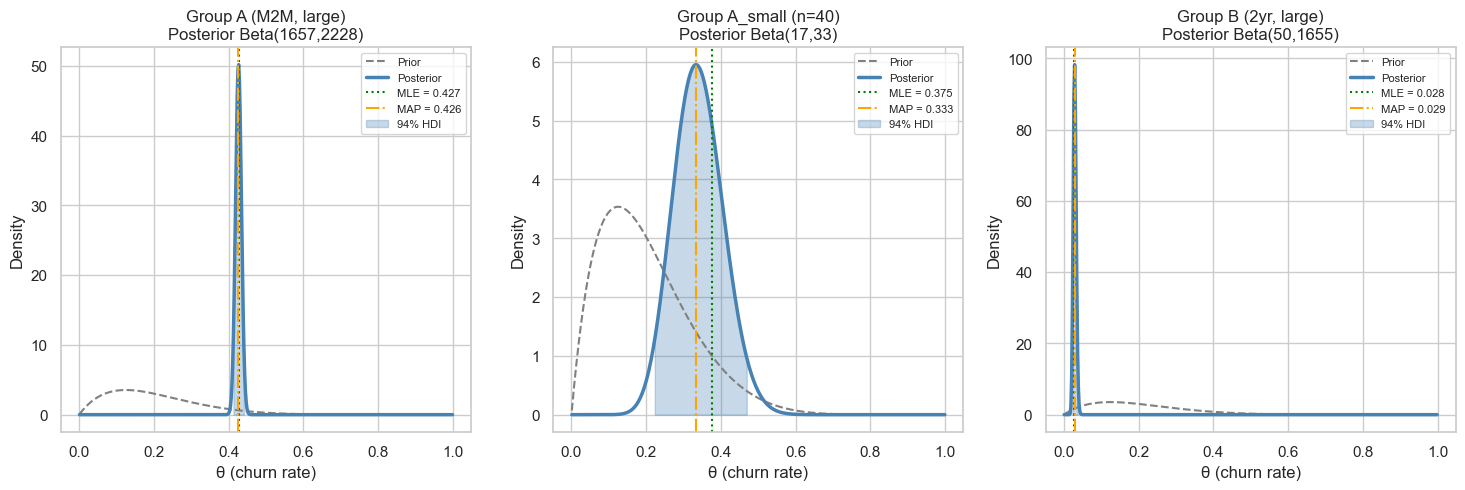

In [4]:
theta_range = np.linspace(0.001, 0.999, 500)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (k, n)) in zip(axes, groups.items()):
    alpha_post = alpha_prior + k
    beta_post = beta_prior + (n - k)

    # Prior PDF
    prior_pdf = beta_dist.pdf(theta_range, alpha_prior, beta_prior)
    ax.plot(theta_range, prior_pdf, "gray", linestyle="--", label="Prior")

    # Posterior PDF
    post_pdf = beta_dist.pdf(theta_range, alpha_post, beta_post)
    ax.plot(theta_range, post_pdf, "steelblue", lw=2.5, label="Posterior")

    # MLE and MAP lines
    mle_val = k / n
    map_val = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    ax.axvline(mle_val, color="green", linestyle=":", label=f"MLE = {mle_val:.3f}")
    ax.axvline(map_val, color="orange", linestyle="-.", label=f"MAP = {map_val:.3f}")

    # 94% HDI
    hdi_low, hdi_high = beta_dist.ppf([0.03, 0.97], alpha_post, beta_post)
    ax.fill_between(
        theta_range,
        0,
        post_pdf,
        where=(theta_range >= hdi_low) & (theta_range <= hdi_high),
        color="steelblue",
        alpha=0.3,
        label="94% HDI",
    )

    ax.set_title(f"{name}\nPosterior Beta({alpha_post:.0f},{beta_post:.0f})")
    ax.set_xlabel("θ (churn rate)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

### Q3 — Answer the VP's question: P(θ_A > θ_B)

Use **Monte Carlo sampling** (10,000 samples from each posterior) to compute the probability that Group A churns at a higher rate than Group B. No p-value permitted.


In [5]:
MC_SAMPLES = 10_000
np.random.seed(42)

# Posterior parameters for Group A and Group B
alpha_post_A = alpha_prior + k_A
beta_post_A = beta_prior + n_A - k_A

alpha_post_B = alpha_prior + k_B
beta_post_B = beta_prior + n_B - k_B

# Draw samples
post_A_samples = np.random.beta(alpha_post_A, beta_post_A, MC_SAMPLES)
post_B_samples = np.random.beta(alpha_post_B, beta_post_B, MC_SAMPLES)

# Probability that θ_A > θ_B
p_A_greater = np.mean(post_A_samples > post_B_samples)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert 0.90 < p_A_greater <= 1.0, f"Expected P > 0.90, got {p_A_greater:.4f}"
print(f"P(θ_A > θ_B) = {p_A_greater:.4f}")
print(
    f"→ We can tell the VP that Month-to-month churns at a higher rate with "
    f"{p_A_greater*100:.1f}% probability — without a p-value."
)

P(θ_A > θ_B) = 1.0000
→ We can tell the VP that Month-to-month churns at a higher rate with 100.0% probability — without a p-value.


✍️ **Reflect 1 — MLE vs MAP vs Full Bayes:**

For Group A_small (n=40), the three approaches give different answers.

## 1. What is the **prior pull** (|MAP − MLE|) for Group A_small vs Group B (large)? Why is it larger for the small group?

> ANS:: The prior pull for Group A_small is 0.0417, which is much larger than Group B (0.0005). 
> The mathematical formulas are: 
> $$ MLE = \frac{k}{n}  $$
> $$\text{MAP} = \frac{k + (\alpha - 1)}{n + (\alpha + \beta - 2)} = \frac{k + 1}{n + 8} \quad \text{for } \text{Beta}(2,8)$$
> Small Group (n = 40): Because the data counts (k and n) are very small, the prior constants (+1 and +8) heavily shift the fraction. This pulls the MAP estimate away from the MLE, creating a large prior pull (0.0417).
> Large Group (n = 1695): Because n and k are massive, adding +1 and +8 is mathematically unnoticeable. The real-world data completely overwhelms the prior constants, forcing MAP to converge almost perfectly onto the MLE (prior pull of 0.0005).

## 2. Which estimate would you present to the VP for Group A_small and why? What does each estimate provide that the others do not?

> ANS:: For Group A_small, I would present the Full Bayes approach, explicitly reporting the 94% Credible Interval (HDI) rather than a single point estimate. 
> Justification & Comparison:- Point estimates can be highly misleading when dealing with small sample sizes ($n=40$). Reporting the full distribution prevents making risky, reactive business decisions based on a handful of data points.
> Here is what each metric uniquely provides and lacks:
> MLE (0.3750): Provides a raw snapshot of the current sample data. However, it completely lacks historical context and overestimates the churn threat due to random small-sample noise.
> MAP (0.3333): Provides a single, balanced point guess. It incorporates corporate history to naturally pull down the noisy MLE estimate to a more realistic figure, but it still fails to communicate our level of uncertainty to leadership.
> Full Bayes (94% HDI): Provides a complete range of certainty (the entire posterior distribution). Instead of giving a deceptively precise single number, it lets us tell the VP exactly how confident we are quantifying the real business risk by showing the boundaries within which the true churn rate sits.

## 3. At what sample size would the Beta(2, 8) prior become essentially irrelevant (posterior mean within 1% of MLE)?

> ANS:: The formula for the Bayesian posterior mean is:$$\text{Posterior Mean} = \frac{k + \alpha}{n + \alpha + \beta}     $$ where: $\alpha$ and $\beta$ are priors. 
> Substituting our prior values ($\alpha=2, \beta=8$), the formula becomes:
> $$\text{Posterior Mean} = \frac{k + 2}{n + 10}$$
> The prior acts as if we already have $10$ historical customer cases in the denominator ($2 + 8 = 10$). When our real-world sample size ($n$) hits 1,000, those 10 prior cases make up exactly 1% of the total weight ($\frac{10}{1000} = 1\%$). As $n$ grows beyond 1,000, the $+10$ becomes mathematically invisible, forcing the Bayesian formula to become identical to the MLE formula ($\frac{k}{n}$).

---
## Part 2: Sequential Bayesian Updating & Dirichlet-Multinomial

---

### Q4 — Implement the sequential update function


In [6]:
def update_posterior(alpha, beta, churn_label):
    if churn_label == 1:
        return (alpha + 1, beta)
    else:
        return (alpha, beta + 1)


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
a0, b0 = 2.0, 8.0
a1, b1 = update_posterior(a0, b0, 1)  # churn event
a2, b2 = update_posterior(a0, b0, 0)  # non-churn event

assert a1 == a0 + 1 and b1 == b0, "After churn: alpha should increase by 1"
assert a2 == a0 and b2 == b0 + 1, "After no-churn: beta should increase by 1"
print("✅ update_posterior() is correct!")

✅ update_posterior() is correct!


### Q5 — Run sequential update and plot posterior evolution


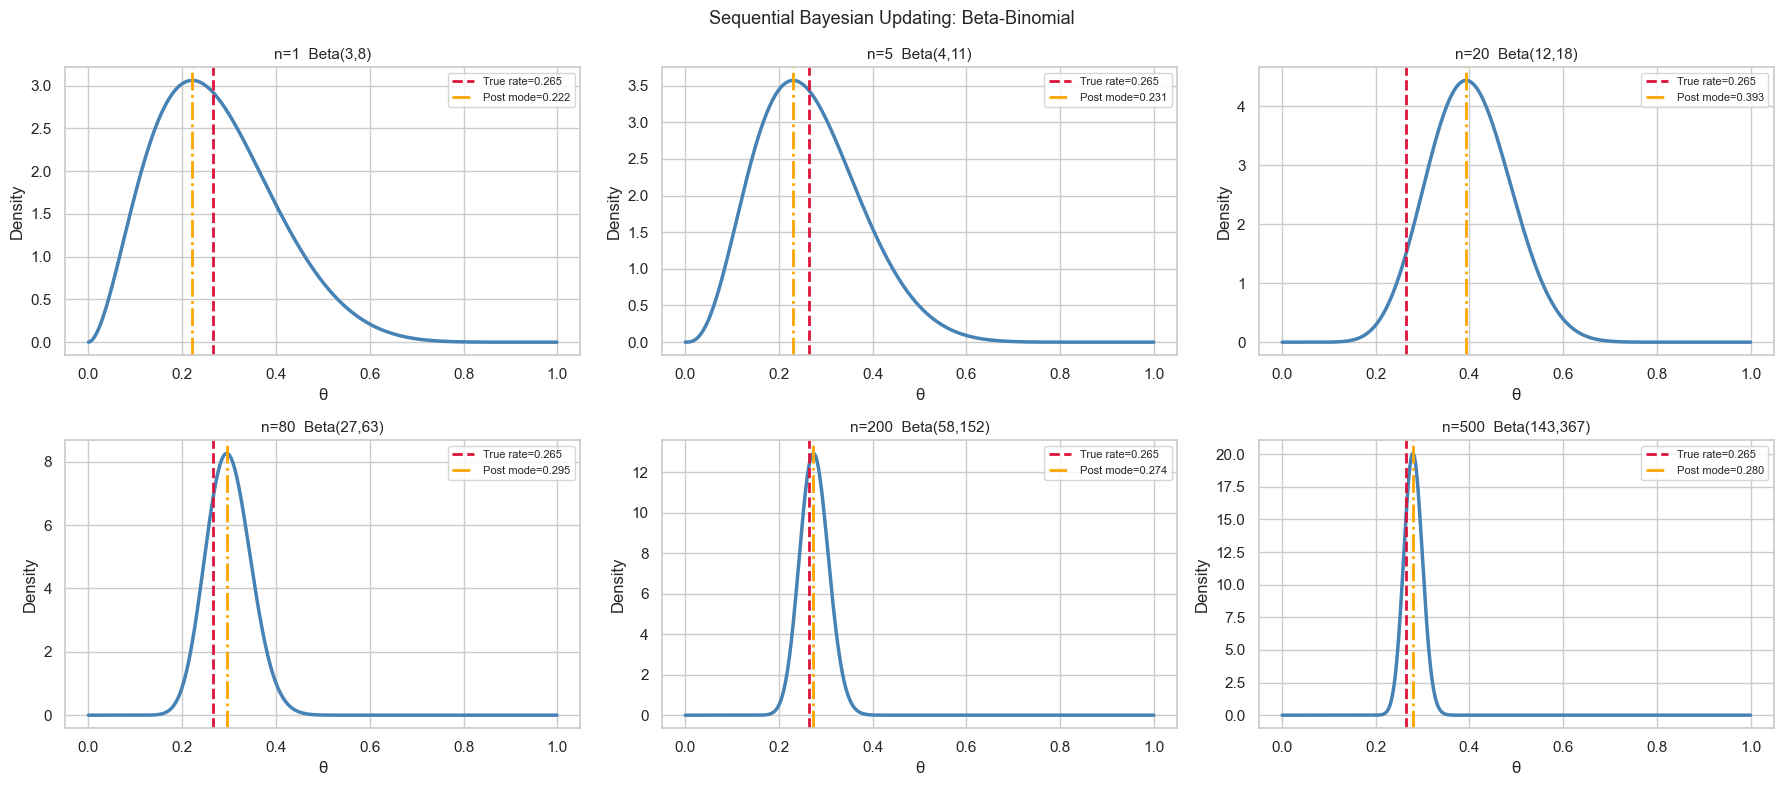

In [7]:
# Shuffle the Telco dataset (fixed seed)
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
TRUE_RATE = df["Churn"].mean()

snapshots = [1, 5, 20, 80, 200, 500]

# YOUR CODE HERE:
# 1. Start with Beta(2, 8)
# 2. Run update_posterior on the first 500 rows of df_shuffled
# 3. Record (alpha, beta) at each snapshot n
# Store results as a dict: {n: (alpha_n, beta_n)}
alpha, beta = 2.0, 8.0
history = {}  # {n: (alpha_n, beta_n)}

for i in range(500):
    # Update using the i-th customer's Churn value (0 or 1)
    alpha, beta = update_posterior(alpha, beta, df_shuffled.loc[i, "Churn"])

    # If this index+1 is one of the snapshot sizes, record
    n_obs = i + 1
    if n_obs in snapshots:
        history[n_obs] = (alpha, beta)

# Plot (runs after history is populated)
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, n in zip(axes.flat, snapshots):
    a_n, b_n = history[n]
    pdf = beta_dist.pdf(theta_r, a_n, b_n)
    mode = (a_n - 1) / (a_n + b_n - 2)
    ax.plot(theta_r, pdf, color="steelblue", lw=2.5)
    ax.axvline(
        TRUE_RATE, color="crimson", ls="--", lw=2, label=f"True rate={TRUE_RATE:.3f}"
    )
    ax.axvline(mode, color="orange", ls="-.", lw=2, label=f"Post mode={mode:.3f}")
    ax.set_title(f"n={n}  Beta({a_n:.0f},{b_n:.0f})", fontsize=11)
    ax.set_xlabel("θ")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
plt.suptitle("Sequential Bayesian Updating: Beta-Binomial", fontsize=13)
plt.tight_layout()
plt.show()

### Q6 — Decision boundary: P(θ > 0.25) vs n


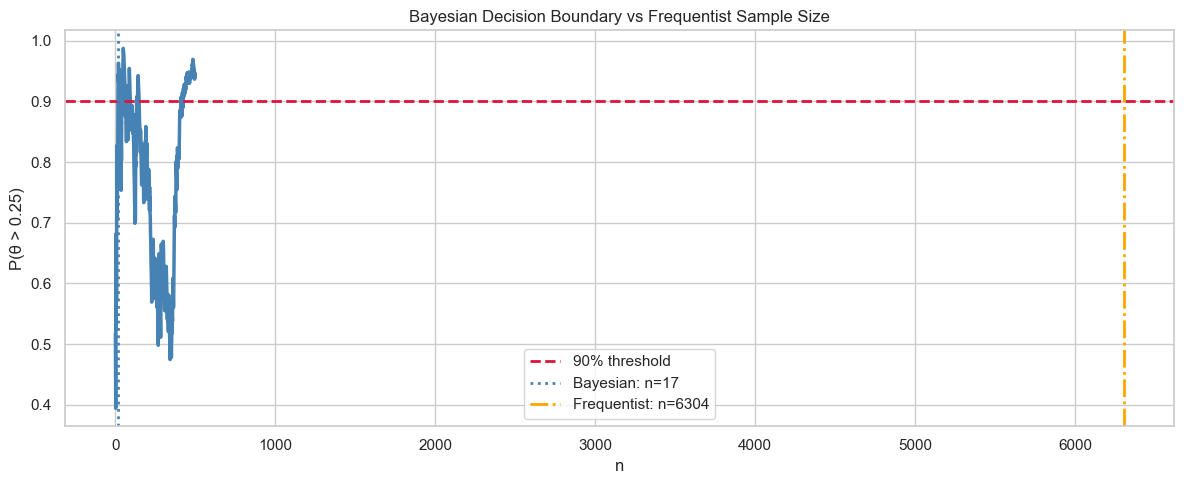

Bayesian: n = 17  |  Frequentist: n = 6304


In [8]:
threshold = 0.25
MC_SAMPLES = 10_000
np.random.seed(0)

# Run through the first 500 shuffled rows
# At each step, compute P(θ > threshold) by sampling 10,000 values from the current posterior
# Store as a list p_exceed (length 500)
p_exceed = []
alpha_seq, beta_seq = 2.0, 8.0

for i in range(500):
    # Update posterior with i-th customer's Churn
    alpha_seq, beta_seq = update_posterior(
        alpha_seq, beta_seq, df_shuffled.loc[i, "Churn"]
    )

    # Draw samples from current posterior
    samples = np.random.beta(alpha_seq, beta_seq, MC_SAMPLES)

    # Compute P(θ > threshold)
    prob = np.mean(samples > threshold)
    p_exceed.append(prob)

# Frequentist sample size (one-proportion z-test, alpha=0.05, power=0.80)
from scipy.stats import norm

z_a, z_b = norm.ppf(0.975), norm.ppf(0.80)
p0, p1 = threshold, TRUE_RATE
freq_n = int(
    np.ceil(
        (z_a * np.sqrt(p0 * (1 - p0)) + z_b * np.sqrt(p1 * (1 - p1))) ** 2
        / (p1 - p0) ** 2
    )
)

# Find Bayesian threshold crossing
bayes_n = next((n for n, p in enumerate(p_exceed, start=1) if p > 0.90), None)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(p_exceed) + 1), p_exceed, color="steelblue", lw=2.5)
ax.axhline(0.90, color="crimson", ls="--", lw=2, label="90% threshold")
if bayes_n:
    ax.axvline(bayes_n, color="steelblue", ls=":", lw=2, label=f"Bayesian: n={bayes_n}")
ax.axvline(freq_n, color="orange", ls="-.", lw=2, label=f"Frequentist: n={freq_n}")
ax.set_xlabel("n")
ax.set_ylabel("P(θ > 0.25)")
ax.legend()
ax.set_title("Bayesian Decision Boundary vs Frequentist Sample Size")
plt.tight_layout()
plt.show()

print(f"Bayesian: n = {bayes_n}  |  Frequentist: n = {freq_n}")

### Q7 — Dirichlet-Multinomial: 3-category contract type


Posterior Dirichlet params: [3876. 1474. 1696.]
Posterior means: [0.55009935 0.20919671 0.24070395]
MLE proportions: [0.55019168 0.20914383 0.24066449]
✅ Dirichlet posterior computed!


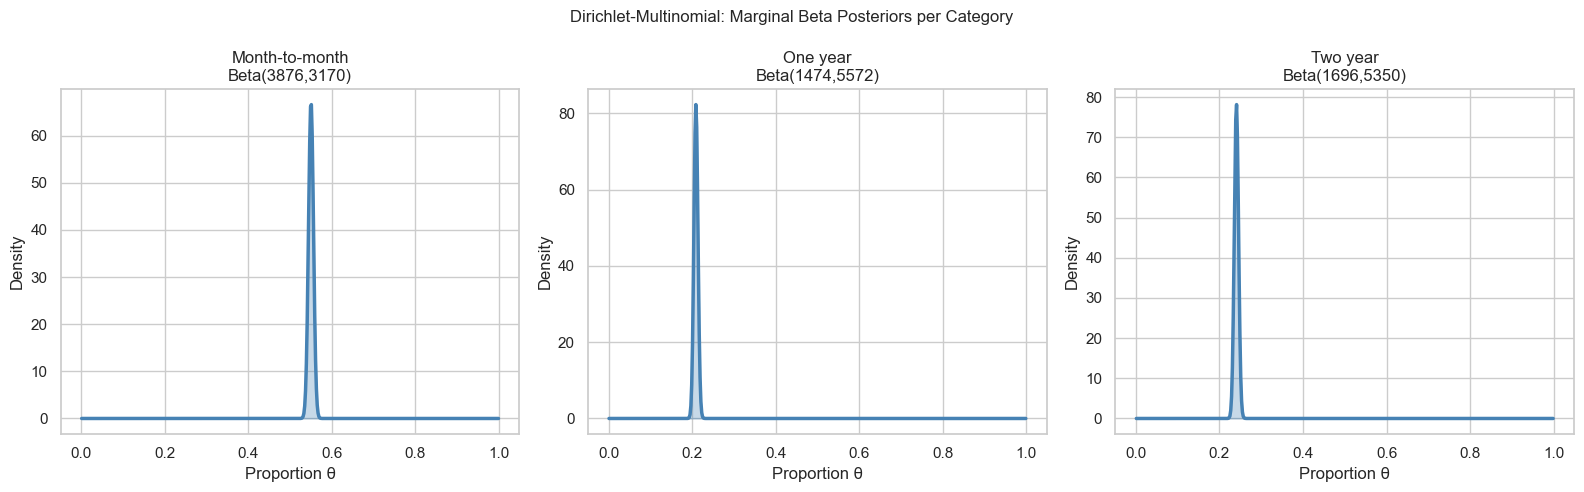

In [9]:
categories = ["Month-to-month", "One year", "Two year"]
prior_alpha = np.array([1.0, 1.0, 1.0])  # flat Dirichlet prior — do not change

# 1. Count observations for each contract category in the full dataset
# 2. Compute posterior Dirichlet parameters = prior + counts
# 3. Report posterior means for each category

# Count observations for each category in the full dataset
counts = np.array(
    [
        len(df[df["Contract"] == "Month-to-month"]),
        len(df[df["Contract"] == "One year"]),
        len(df[df["Contract"] == "Two year"]),
    ]
)

posterior_alpha = prior_alpha + counts

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert len(posterior_alpha) == 3
assert posterior_alpha.sum() == prior_alpha.sum() + counts.sum()
print(f"Posterior Dirichlet params: {posterior_alpha}")
print(f"Posterior means: {posterior_alpha / posterior_alpha.sum()}")
print(f"MLE proportions: {counts / counts.sum()}")
print("✅ Dirichlet posterior computed!")

# Plot marginal Beta posteriors for each category
theta_r = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (cat, a_j) in zip(axes, zip(categories, posterior_alpha)):
    b_j = posterior_alpha.sum() - a_j
    pdf = beta_dist.pdf(theta_r, a_j, b_j)
    ax.plot(theta_r, pdf, color="steelblue", lw=2.5)
    ax.fill_between(theta_r, 0, pdf, alpha=0.3, color="steelblue")
    ax.set_title(f"{cat}\nBeta({a_j:.0f},{b_j:.0f})")
    ax.set_xlabel("Proportion θ")
    ax.set_ylabel("Density")

plt.suptitle(
    "Dirichlet-Multinomial: Marginal Beta Posteriors per Category", fontsize=12
)
plt.tight_layout()
plt.show()

In [10]:
new_alpha_4cat = np.append(posterior_alpha, 1.0)  # pseudocount 1 for Biannual

print("Posterior for unseen 'Biannual' category:")
a_biannual = new_alpha_4cat[3]
b_biannual = new_alpha_4cat.sum() - a_biannual
post_mean_biannual = a_biannual / new_alpha_4cat.sum()
print(f"  Posterior mean: {post_mean_biannual:.4f}")
print(f"  Equivalent to Beta({a_biannual:.1f}, {b_biannual:.1f})")

Posterior for unseen 'Biannual' category:
  Posterior mean: 0.0001
  Equivalent to Beta(1.0, 7046.0)


✍️ **Reflect 2 — Dirichlet-Multinomial:**

## 1. Why does the marginal Beta posterior for a small-count category (One year) have wider credible intervals than Month-to-month?
> ANS:: The width of a Beta distribution’s credible interval is driven by the total number of observations collected for that group. For Month-to-month, our dataset contains a massive sample size ($a_j = 3876$), meaning our uncertainty is very low, resulting in a tall, narrow, and highly precise peak. For One year, our sample size is much smaller ($a_j = 1474$). Because we have fewer observations to learn from, our statistical uncertainty is naturally higher, which forces its marginal Beta distribution curve to flatten out and become wider.

## 2. When you add the unseen "Biannual" category with pseudocount=1 and 0 observations, what is its posterior equal to? What does this reveal about the Dirichlet prior?
> ANS:: With 0 real-world observations and a starting pseudocount of 1, the posterior for our unseen "Biannual" category is exactly equal to $\text{Beta}(1.0, 7046.0)$, yielding a tiny posterior mean of 0.0001. This demonstrates that the Dirichlet prior provides built-in regularization, effectively performing Laplace Smoothing. Instead of allowing zero-count categories to break our model by assigning an unrealistic frequentist probability of absolute $0\%$, the Dirichlet prior ensures every category retains a non-zero chance of occurring. It prevents our model from confidently believing that unobserved events are mathematically impossible.

## 3. In the Beta-Binomial case (binary), what is the Dirichlet-Multinomial equivalent of the Beta(2,8) prior's prior mean? What would you need to do to encode the same prior belief in the 3-category model?
> ANS:: In our binary Beta-Binomial case, a Beta(2, 8) prior carries a prior mean of $\frac{2}{2+8} = 20\%$ for the event of interest, representing a total strength of $10$ pseudo-observations. To encode this exact same historical baseline belief into our 3-category Dirichlet model while preserving the total prior strength of $10$ observations, our prior vector elements must sum to $10$ and maintain the target category at a 20% proportion. For instance, if we want our first category to mirror the $20\%$ baseline from the binary model, we would structure our Dirichlet prior as:$$\alpha_{\text{prior}} = [2.0, \, 4.0, \, 4.0]$$

---
## Part 3: Multivariate Gaussians — When Features Correlate

---

### Q8 — Fit a 2D Gaussian and plot confidence ellipses


In [11]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

features_2d = ["tenure", "MonthlyCharges"]
X_2d = df[features_2d].values.astype(float)

# Compute the empirical mean vector and covariance matrix
# Report correlation ρ = Σ_12 / sqrt(Σ_11 * Σ_22)

mu_2d = np.mean(X_2d, axis=0)  # shape (2,)
Sigma_2d = np.cov(X_2d.T)  # shape (2,2)
rho = Sigma_2d[0, 1] / np.sqrt(Sigma_2d[0, 0] * Sigma_2d[1, 1])

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert mu_2d.shape == (2,), f"mu should have shape (2,), got {mu_2d.shape}"
assert Sigma_2d.shape == (2, 2), f"Sigma should be 2x2, got {Sigma_2d.shape}"
assert -1 < rho < 1, f"rho should be between -1 and 1, got {rho:.4f}"
print(f"μ = {np.round(mu_2d, 2)}")
print(f"Σ = \n{np.round(Sigma_2d, 2)}")
print(f"ρ = {rho:.4f}")
print("✅ 2D Gaussian fitted!")

μ = [32.37 64.76]
Σ = 
[[603.17 183.2 ]
 [183.2  905.41]]
ρ = 0.2479
✅ 2D Gaussian fitted!


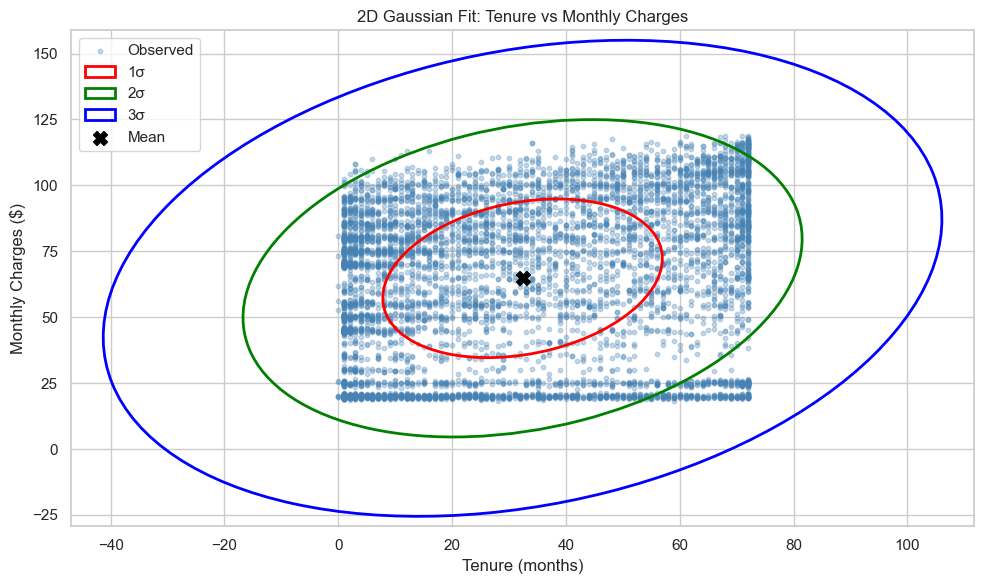

In [12]:
def confidence_ellipse(mu, cov, ax, n_std=1.0, facecolor="none", **kwargs):
    w, v = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(v[1, 0], v[0, 0]))
    ell = Ellipse(
        (0, 0),
        width=2 * n_std * np.sqrt(w[0]),
        height=2 * n_std * np.sqrt(w[1]),
        angle=angle,
        facecolor=facecolor,
        **kwargs,
    )
    t = transforms.Affine2D().translate(*mu) + ax.transData
    ell.set_transform(t)
    return ax.add_patch(ell)


fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
ax.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.3, s=10, c="steelblue", label="Observed")


colors = ["red", "green", "blue"]
# Confidence ellipses
for n_std in [1, 2, 3]:
    confidence_ellipse(
        mu_2d,
        Sigma_2d,
        ax,
        n_std=n_std,
        edgecolor=colors[n_std - 1],
        linestyle="-",
        linewidth=2,
        facecolor="none",
        label=f"{n_std}σ",
    )

# Mean point
ax.scatter(*mu_2d, color="black", s=100, marker="X", label="Mean", zorder=5)

ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Monthly Charges ($)")
ax.set_title("2D Gaussian Fit: Tenure vs Monthly Charges")
ax.legend()
plt.tight_layout()
plt.show()

### Q9 — Conditional Gaussian: MonthlyCharges | tenure = 24

Write out the formula **before coding it**:
$$\mu_{1|2} = \mu_1 + \Sigma_{12}\Sigma_{22}^{-1}(x_2 - \mu_2)$$
$$\sigma^2_{1|2} = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$$


In [13]:
# compute the conditional distribution P(MonthlyCharges | tenure = 24)
# Index convention: X_1 = MonthlyCharges (index 1 in X_2d), X_2 = tenure (index 0)
tenure_query = 24

# Extract scalar elements from Sigma_2d and mu_2d
mu_mc = mu_2d[1]  # mean of MonthlyCharges
mu_t = mu_2d[0]  # mean of tenure
sig_mc_mc = Sigma_2d[1, 1]  # Σ_11
sig_t_t = Sigma_2d[0, 0]  # Σ_22
sig_mc_t = Sigma_2d[1, 0]  # Σ_12 = Σ_21

# apply the conditional Gaussian formula
cond_mean = mu_mc + (sig_mc_t / sig_t_t) * (tenure_query - mu_t)
cond_var = sig_mc_mc - (sig_mc_t**2) / sig_t_t
cond_std = np.sqrt(cond_var)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
near_24 = df[(df["tenure"] >= 22) & (df["tenure"] <= 26)]["MonthlyCharges"].mean()
assert (
    abs(cond_mean - near_24) < 10
), f"Conditional mean {cond_mean:.2f} too far from empirical {near_24:.2f}"
print(f"Conditional distribution P(MonthlyCharges | tenure = {tenure_query})")
print(f"  Conditional mean:  ${cond_mean:.2f}/month")
print(f"  Conditional std:   ${cond_std:.2f}/month")
print(
    f"  95% interval:      [${cond_mean - 1.96*cond_std:.2f}, ${cond_mean + 1.96*cond_std:.2f}]"
)
print(f"  Empirical check:   ${near_24:.2f}  ← should be within ~$5")
print("✅ Conditional Gaussian computed!")

Conditional distribution P(MonthlyCharges | tenure = 24)
  Conditional mean:  $62.22/month
  Conditional std:   $29.15/month
  95% interval:      [$5.08, $119.35]
  Empirical check:   $61.81  ← should be within ~$5
✅ Conditional Gaussian computed!


### Q10 — 3D Covariance and Condition Number


In [14]:
features_3d = ["tenure", "MonthlyCharges", "TotalCharges"]
X_3d = df[features_3d].values.astype(float)

# 1. Compute Sigma_3d = np.cov(X_3d.T)
# 2. Compute condition number kappa = np.linalg.cond(Sigma_3d)
# 3. Marginalise out TotalCharges by extracting the 2×2 upper-left block
# 4. Verify this matches Sigma_2d (should be identical)

Sigma_3d = np.cov(X_3d.T)  # 3x3 covariance matrix
kappa = np.linalg.cond(Sigma_3d)  # condition number
Sigma_marginal = Sigma_3d[:2, :2]
max_diff = np.max(np.abs(Sigma_marginal - Sigma_2d))

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert Sigma_3d.shape == (3, 3)
assert kappa > 100, f"Expected high condition number, got {kappa:.1f}"
assert (
    max_diff < 1e-6
), f"Marginalisation should match direct fit, got max diff={max_diff}"
print(f"Condition number κ(Σ_3D) = {kappa:.1f}")
print(f"Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = {max_diff:.2e}  ✅")

Condition number κ(Σ_3D) = 58988.9
Marginalisation check: max |Σ_2D - Σ_3D[:2,:2]| = 0.00e+00  ✅


✍️ **Reflect 3 — Multivariate Gaussians:**

## 1. The condition number κ(Σ_3D) should be large (>> 100). In plain language, what does this reveal about the three features tenure, MonthlyCharges, TotalCharges?
>  ANS:: This reveals that our three features are highly redundant because TotalCharges is roughly just a product of tenure and MonthlyCharges. In plain language, this massive multicollinearity means our 3D data points do not fill up a 3D volume; instead, they collapse into a flat, narrow 2D sheet, making one of our variables completely unnecessary.

## 2. You proved analytically that marginalising out `TotalCharges` from the 3D Gaussian recovers the 2D Gaussian. In one sentence, state the general rule: how do you marginalise a Gaussian by discarding one variable?
> ANS:: To marginalize a Gaussian distribution, we simply discard the rows and columns corresponding to the unwanted variables from the mean vector and covariance matrix, without needing to reprocess our raw dataset.

## 3. Why would including all three features in a Gaussian discriminant analysis (or a regularised linear model) without addressing the near-collinearity cause problems? Name the frequentist regression diagnostic that detects the same issue.
> ANS:: Including all three near-collinear features makes our covariance matrix nearly singular (uninvertible), which breaks the mathematical foundation of Gaussian discriminant analysis and leads to unstable, unreliable predictions. The frequentist regression diagnostic that detects this issue is the Variance Inflation Factor (VIF), which quantifies how much the variance of a regression coefficient is inflated due to multicollinearity. A VIF value above 10 is often considered a red flag for severe multicollinearity.

---
## Part 4: Probabilistic Graphical Models — Bayesian Networks and MRFs

---

### Q11 — Build and fit a Bayesian Network with pgmpy


In [15]:
# Prepare discretised dataframe
df_pgm = df[
    [
        "SeniorCitizen",
        "Contract",
        "tenure",
        "InternetService",
        "MonthlyCharges",
        "Churn",
    ]
].copy()

df_pgm["tenure_disc"] = pd.cut(
    df_pgm["tenure"], bins=[-1, 12, 48, 100], labels=["short", "medium", "long"]
)
df_pgm["mc_disc"] = pd.qcut(
    df_pgm["MonthlyCharges"], q=3, labels=["low", "mid", "high"]
)
df_pgm = df_pgm.drop(columns=["tenure", "MonthlyCharges"]).dropna().astype(str)

# define the DAG structure as a list of (parent, child) tuples
# DAG: SeniorCitizen→Churn, Contract→Churn, tenure_disc→Churn,
#      InternetService→mc_disc, mc_disc→Churn
dag_edges = [
    ("SeniorCitizen", "Churn"),
    ("Contract", "Churn"),
    ("tenure_disc", "Churn"),
    ("InternetService", "mc_disc"),
    ("mc_disc", "Churn"),
]
dag = DiscreteBayesianNetwork(dag_edges)
dag.fit(df_pgm, estimator=DiscreteMLE())
print("✅ Bayesian Network fitted.")
print(f"   Nodes: {list(dag.nodes())}")
print(f"   Edges: {list(dag.edges())}")

✅ Bayesian Network fitted.
   Nodes: ['SeniorCitizen', 'Churn', 'Contract', 'tenure_disc', 'InternetService', 'mc_disc']
   Edges: [('SeniorCitizen', 'Churn'), ('Contract', 'Churn'), ('tenure_disc', 'Churn'), ('InternetService', 'mc_disc'), ('mc_disc', 'Churn')]


In [16]:
infer = VariableElimination(dag)

# forward inference
# P(Churn | Contract = 'Month-to-month')
result_fwd = infer.query(variables=["Churn"], evidence={"Contract": "Month-to-month"})
p_churn_m2m_bn = result_fwd.values[1]  # index 1 corresponds to Churn=1
emp_m2m = df[df["Contract"] == "Month-to-month"]["Churn"].mean()

print(f"BN inference P(Churn=1 | Contract=M2M): {p_churn_m2m_bn:.4f}")
print(f"Empirical:                              {emp_m2m:.4f}")
print(f"Discrepancy: {abs(p_churn_m2m_bn - emp_m2m):.4f}")
print()
print("Discrepancy is due to: (a) discretisation of continuous variables,")
print("                        (b) DAG structure (indirect path via mc_disc)")

BN inference P(Churn=1 | Contract=M2M): 0.3542
Empirical:                              0.4271
Discrepancy: 0.0729

Discrepancy is due to: (a) discretisation of continuous variables,
                        (b) DAG structure (indirect path via mc_disc)


In [17]:
# backward inference (explaining away)
# P(Contract | Churn = '1') — what does Bayesian inversion tell us?
result_bwd = infer.query(variables=["Contract"], evidence={"Churn": "1"})

print("Backward inference P(Contract | Churn = 1):")
print(result_bwd)
print()
print("Interpretation for retention manager:")
print("  This tells us: given a customer has churned, what is the probability they")
print("  were on each contract type? This is the INVERSE of the forward prediction.")

Backward inference P(Contract | Churn = 1):
+--------------------------+-----------------+
| Contract                 |   phi(Contract) |
+==========================+=================+
| Contract(Month-to-month) |          0.8017 |
+--------------------------+-----------------+
| Contract(One year)       |          0.1118 |
+--------------------------+-----------------+
| Contract(Two year)       |          0.0865 |
+--------------------------+-----------------+

Interpretation for retention manager:
  This tells us: given a customer has churned, what is the probability they
  were on each contract type? This is the INVERSE of the forward prediction.


### Q12 — Structure sensitivity: two competing DAGs

Draw both DAGs below (ASCII or text description). Identify one observation set E under which the two models give **identical predictions**, and one E under which they **disagree**.


**DAG 1 (original):** `tenure → Churn` (direct edge)

```
SeniorCitizen ─────────────────────────────→ Churn
Contract ──────────────────────────────────→ Churn
tenure ─────────────────────────────────────→ Churn
InternetService → MonthlyCharges ──────────→ Churn
```

**DAG 2 (colleague's proposal):** `Contract → tenure → Churn` (mediated path)

```
          Contract
             ↓
          tenure_disc
             ↓
           Churn ← SeniorCitizen
             ↑
        mc_disc ← InternetService
```

**Observation set E where both models agree:** 
> $E = \{\text{Contract}, \, \text{tenure\_disc}\}$ (Observing both variables simultaneously). When we fix and condition on both variables at the same time, the direct parent-child relationship in DAG 1 and the mediated path in DAG 2 isolate Churn identically. Because the exact values for both nodes are explicitly given in our evidence dictionary, the difference in how the arrows connect them becomes mathematically irrelevant to the final calculation of $P(\text{Churn} \mid E)$.

**Observation set E where models disagree:** 
> $E = \{\text{Contract}\}$ (Observing only the contract type). In DAG 1, Contract and tenure_disc are completely independent root causes of Churn. If we only observe Contract, our network keeps the probability distribution of tenure_disc at its general population baseline. In DAG 2, however, Contract directly alters our belief about tenure_disc (e.g., a Month-to-month contract strongly implies a short tenure). This conditional flow changes the input distribution to Churn, forcing the two models to give structurally different numerical predictions.

**Which causal story is more consistent with W5 SHAP findings?** 
> DAG 1 (Our Original Direct Edge Model) is much more consistent with our SHAP findings. Looking at our Week 5 SHAP waterfall plot for Customer #34, we can see that a low tenure value (scaled value of $-1.241$) is the single most powerful driver in the entire model, adding a massive $+0.07$ directly to the risk score. Crucially, this happens in addition to the separate $+0.05$ risk contribution added by Contract_Month-to-month = 1.


### Q13 — Markov Random Field: undirected model


In [18]:
# Build a DiscreteMarkovNetwork with the same 4 variables (undirected edges)
# Define pairwise DiscreteFactor objects from joint empirical frequencies
# Run BeliefPropagation to compute P(Churn)
# Compare to the BN's P(Churn) and the empirical base rate
from pgmpy.models import DiscreteMarkovNetwork
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import BeliefPropagation

# Define undirected edges (same as DAG but without direction)
mrf_edges = [
    ("SeniorCitizen", "Churn"),
    ("Contract", "Churn"),
    ("tenure_disc", "Churn"),
    ("InternetService", "mc_disc"),
    ("mc_disc", "Churn"),
]

mrf = DiscreteMarkovNetwork(mrf_edges)
bp = BeliefPropagation(mrf)
marg_churn = bp.query(variables=["Churn"], show_progress=False)

print("MRF P(Churn):", marg_churn)
print(f"BN  P(Churn=1): {float(infer.query(['Churn']).values[1]):.4f}")
print(f"Empirical:      {df['Churn'].mean():.4f}")

MRF P(Churn): ++
++
BN  P(Churn=1): 0.2431
Empirical:      0.2654


✍️ **Reflect 4 — PGMs:**

## 1. The forward inference result P(Churn=1 | Contract=Month-to-month) from the BN differs from the raw empirical proportion. Name the `two specific reasons` for this discrepancy.
> ANS:: The discrepancy between our Bayesian Network's prediction ($0.3542$) and the raw empirical rate ($0.4271$) stems from two specific reasons:   
> - Discretization Loss: Converting our continuous variables (tenure and MonthlyCharges) into coarse, categorical bins (short/medium/long and low/mid/high) throws away granular data and introduces significant quantization error. 
> - Structural Assumptions (Conditional Independence): Our DAG forces a specific independence structure on the variables. For example, InternetService cannot affect Churn directly; it is forced to flow entirely through the mediated path of mc_disc. If this structural assumption doesn't perfectly match reality, the network's calculated joint distribution will deviate from the raw empirical frequencies.

## 2. Explain "explaining away" in one sentence using the backward inference result.
> ANS:: "Explaining away" occurs when we observe an outcome like Churn = 1 and find that one potential cause (such as a customer having a Month-to-month contract with $80.17\%$ probability) becomes so likely that it effectively reduces our statistical need to suspect the other independent causes, like SeniorCitizen status or short tenure.

## 3. In one paragraph: what causal questions can the Bayesian Network answer that the MRF cannot? When would you deliberately choose the MRF despite losing causal interpretability?

> ANS:: Our Bayesian Network can answer explicit directional and interventional causal questions (such as "If we actively force a customer to change their Contract type, how will it impact Churn?") because its directed edges define a clear upstream-downstream hierarchy of cause and effect. The Markov Random Field (MRF) cannot answer these because its undirected edges only capture symmetrical, mutual correlations. However, we would deliberately choose the MRF over the BN when modeling cyclic, bidirectional relationships where variables influence each other simultaneously (such as web page links or spatial image pixels), or when we want to completely avoid the complex mathematical burden of enforcing a strict Directed Acyclic Graph (DAG) structure on our features.


---
## Part 5: Gaussian Process Regression — Mauna Loa CO₂

---

### Q14 — Load the Mauna Loa dataset (3 lines)


In [19]:
from statsmodels.datasets import co2

df_co2 = co2.load_pandas().data.resample("ME").mean().dropna()
t = (df_co2.index - df_co2.index[0]).days.values.reshape(-1, 1) / 365.25
y = df_co2["co2"].values

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert df_co2 is not None
assert t.shape == (len(df_co2), 1), f"t should be shape (n, 1), got {t.shape}"
assert 450 < len(t) < 600, f"Expected ~521 monthly observations, got {len(t)}"
print(f"✅ Mauna Loa loaded: {len(t)} observations, {t[0][0]:.1f}–{t[-1][0]:.1f} years")
print(f"   CO₂ range: {y.min():.1f}–{y.max():.1f} ppm")

✅ Mauna Loa loaded: 521 observations, 0.0–43.8 years
   CO₂ range: 313.4–373.8 ppm


### Q15 — Justify each kernel component before coding

**Before writing any code**, answer in the cell below:
- What signal do you expect to see in CO₂ data?
- What kernel captures the slow upward trend?
- What kernel captures the sharp annual cycle?
- What kernel captures measurement noise?


**Your kernel design rationale:**

| Signal | Description | Kernel choice | Justification |
|--------|-------------|---------------|---------------|
| Trend | *CO₂ has been steadily increasing over decades due to fossil fuel emissions.* | *DotProduct(sigma_0=0.0) (linear kernel)* | *CO₂ rises ~1.5 ppm/year. A DotProduct kernel (k(x,x')=x·x') gives linear extrapolation, which does not revert to the mean. An RBF would revert to the training mean outside the data range, causing large test errors.* |
| Seasonal | *CO₂ oscillates annually (higher in winter, lower in summer) due to plant growth cycles.* | *RBF(1.0) * ExpSineSquared(periodicity=1.0, length_scale=0.1)* | *The product of an RBF (local smoothing) and a periodic kernel (ExpSineSquared) captures a repeating pattern that is also smooth year‑to‑year. Fixed periodicity=1.0 (year).* |
| Noise | *Measurement error and small‑scale variations.* | *WhiteKernel(noise_level=0.1)* | *Accounts for independent Gaussian noise not explained by the structure.* |


In [20]:
# Train/test split: train on indices 0–431 (1958–1993), test on 432+ (1994–2001)
n_train = 432
t_train, y_train = t[:n_train], y[:n_train]
t_test, y_test = t[n_train:], y[n_train:]

# construct the composite kernel
# k_trend    = DotProduct(sigma_0=0.0, sigma_0_bounds='fixed')
#   Hint: CO₂ rises ~1.5 ppm/yr — nearly linear. DotProduct gives k(x,x')=x·x'
#   which extrapolates linearly by construction. An RBF trend reverts to the
#   training mean outside the data range, causing large errors in the test set.
# k_seasonal = RBF(...) * ExpSineSquared(..., periodicity=1.0, periodicity_bounds='fixed')
# k_noise    = WhiteKernel(...)
# kernel     = k_trend + k_seasonal + k_noise

# Construct the composite kernel
k_trend = DotProduct(sigma_0=0.0, sigma_0_bounds="fixed")
k_seasonal = RBF(length_scale=1.0) * ExpSineSquared(
    periodicity=1.0, periodicity_bounds="fixed"
)
k_noise = WhiteKernel(noise_level=0.1)
kernel = k_trend + k_seasonal + k_noise

# Fit the GP
gp = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True, random_state=42
)
gp.fit(t_train, y_train)

print("Optimised kernel:")
print(gp.kernel_)

# Test RMSE
y_test_pred = gp.predict(t_test)
rmse = np.sqrt(np.mean((y_test - y_test_pred) ** 2))
# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert (
    rmse < 4.5
), f"RMSE={rmse:.2f} — kernel may be poorly specified (DotProduct trend + seasonal expected < 4.5 ppm)"
print(f"\n✅ Test RMSE: {rmse:.3f} ppm")

Optimised kernel:
DotProduct(sigma_0=0) + RBF(length_scale=6.67) * ExpSineSquared(length_scale=4.65, periodicity=1) + WhiteKernel(noise_level=0.000754)

✅ Test RMSE: 4.329 ppm


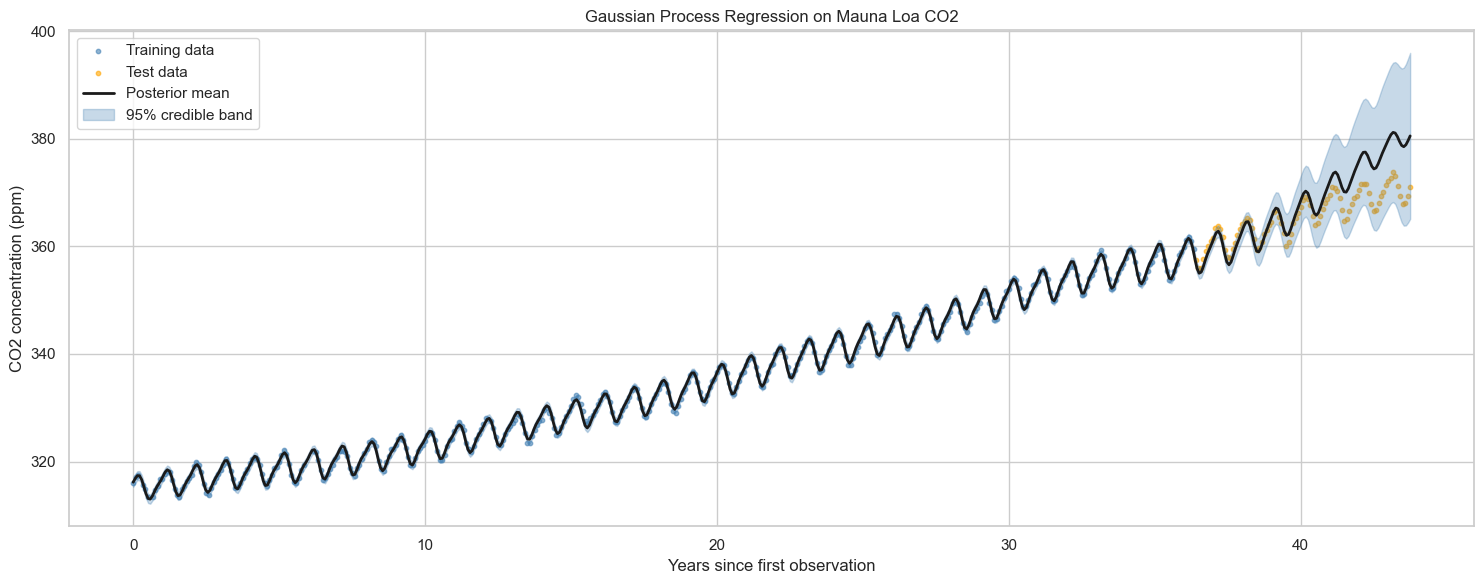

In [21]:
# plot posterior mean and 95% credible bands
# Use gp.predict(t_full, return_std=True) where t_full covers the full training range
# Shade fill_between(mean - 2*std, mean + 2*std) for the 95% band

# Predict over full range (from earliest to latest year)
t_full = np.linspace(t.min(), t.max(), 600).reshape(-1, 1)
y_pred, y_std = gp.predict(t_full, return_std=True)

fig, ax = plt.subplots(figsize=(15, 6))

# Plot training data
ax.scatter(t_train, y_train, c="steelblue", s=10, alpha=0.6, label="Training data")
# Plot test data
ax.scatter(t_test, y_test, c="orange", s=10, alpha=0.6, label="Test data")

# Plot posterior mean
ax.plot(t_full, y_pred, "k-", lw=2, label="Posterior mean")

# Plot 95% credible band (mean ± 2*std)
ax.fill_between(
    t_full.flatten(),
    y_pred - 2 * y_std,
    y_pred + 2 * y_std,
    color="steelblue",
    alpha=0.3,
    label="95% credible band",
)

ax.set_xlabel("Years since first observation")
ax.set_ylabel("CO2 concentration (ppm)")
ax.set_title("Gaussian Process Regression on Mauna Loa CO2")
ax.legend()
plt.tight_layout()
plt.show()

### Q16 — Gap experiment


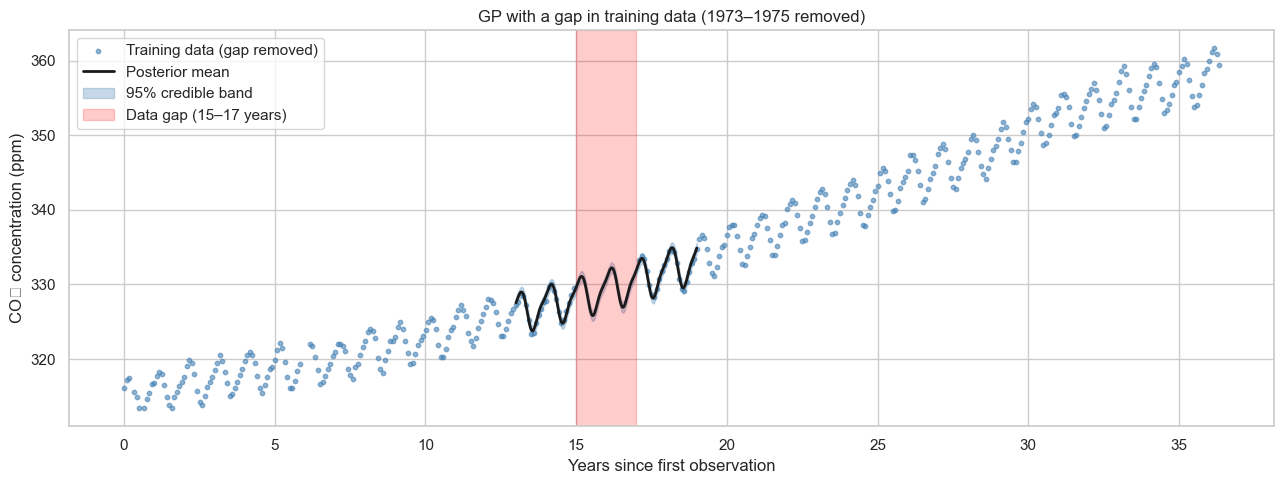

95% band width inside gap:   1.432 ppm
95% band width outside gap:  1.421 ppm
Gap inflation: 1.01×


In [22]:
# Remove all training observations between year 15 and year 17 (~1973–1975)
# Refit the GP on the remaining training data
# Zoom into the gap region and describe how the bands behave inside vs outside the gap

gap_lo, gap_hi = 15.0, 17.0

# Create masks: keep training points outside the gap
# t_train is shape (n_train, 1); we need to flatten for comparison
keep_mask = (t_train.flatten() < gap_lo) | (t_train.flatten() > gap_hi)
t_gap_tr = t_train[keep_mask].reshape(-1, 1)
y_gap_tr = y_train[keep_mask]

gp_gap = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=3, normalize_y=True, random_state=42
)
gp_gap.fit(t_gap_tr, y_gap_tr)

# Predict around the gap and plot
t_zoom = np.linspace(gap_lo - 2, gap_hi + 2, 400).reshape(-1, 1)
y_gz, y_gz_std = gp_gap.predict(t_zoom, return_std=True)

fig, ax = plt.subplots(figsize=(13, 5))

# Plot reduced training data (points outside gap)
ax.scatter(
    t_gap_tr,
    y_gap_tr,
    c="steelblue",
    s=10,
    alpha=0.6,
    label="Training data (gap removed)",
)

# Plot posterior mean
ax.plot(t_zoom, y_gz, "k-", lw=2, label="Posterior mean")

# Plot 95% credible band
ax.fill_between(
    t_zoom.flatten(),
    y_gz - 2 * y_gz_std,
    y_gz + 2 * y_gz_std,
    color="steelblue",
    alpha=0.3,
    label="95% credible band",
)

# Highlight the gap region
ax.axvspan(gap_lo, gap_hi, alpha=0.2, color="red", label="Data gap (15–17 years)")

ax.set_xlabel("Years since first observation")
ax.set_ylabel("CO₂ concentration (ppm)")
ax.set_title("GP with a gap in training data (1973–1975 removed)")
ax.legend()
plt.tight_layout()
plt.show()

# Compute band width inside vs outside gap
band_in = (
    4 * y_gz_std[(t_zoom.flatten() >= gap_lo) & (t_zoom.flatten() <= gap_hi)].mean()
)
band_out = 4 * y_gz_std[t_zoom.flatten() < gap_lo].mean()
print(f"95% band width inside gap:   {band_in:.3f} ppm")
print(f"95% band width outside gap:  {band_out:.3f} ppm")
print(f"Gap inflation: {band_in/band_out:.2f}×")

### Q17 — Extrapolation and the model confidence boundary


At +5 years: 95% band width = 15.03 ppm
At +10 years: 95% band width = 47.68 ppm
At +15 years: 95% band width = 72.53 ppm

Model confidence boundary: +2.2 years beyond training


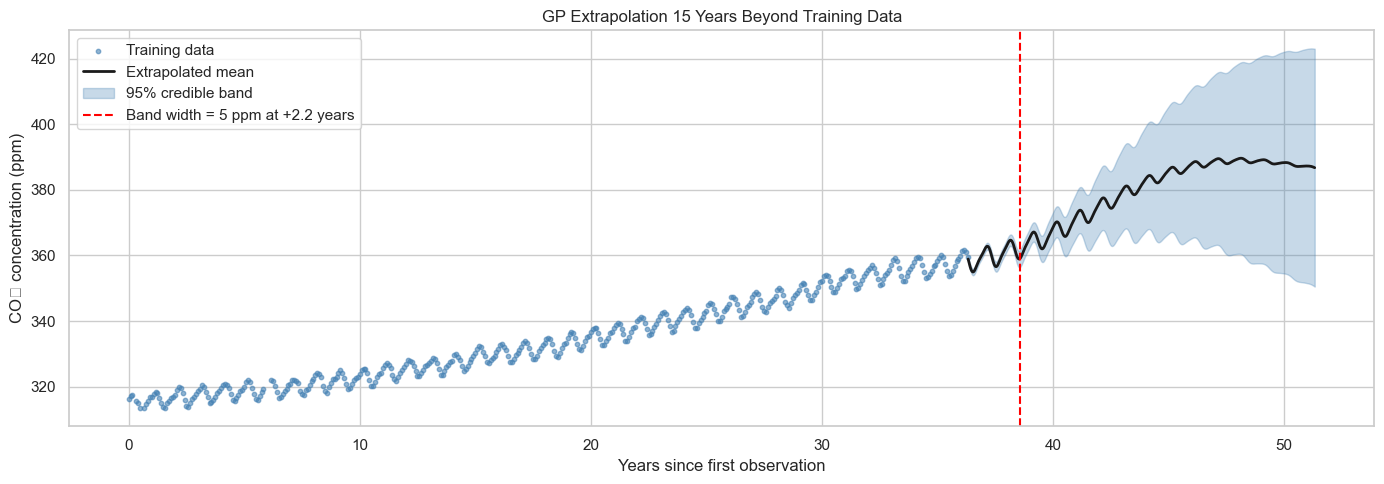

In [23]:
# 1. Predict 15 years beyond the last training point
# 2. Compute the 95% band width at 5, 10, 15 years of extrapolation
# 3. Find the horizon at which the band width first exceeds 5 ppm
# 4. Plot posterior mean + 95% bands for the extrapolation region

t_last = float(t_train.max())  # last training year (~1993)
t_extrap = np.linspace(t_last, t_last + 15, 500).reshape(-1, 1)
y_ex, y_ex_std = gp.predict(t_extrap, return_std=True)

# Compute band widths at 5, 10, 15 years extrapolation
for years in [5, 10, 15]:
    # Find index where time = t_last + years
    target_time = t_last + years
    idx = np.argmin(np.abs(t_extrap.flatten() - target_time))
    band_width = 4 * y_ex_std[idx]  # 95% interval width
    print(f"At +{years} years: 95% band width = {band_width:.2f} ppm")

# Find model confidence boundary (where 95% band > 5 ppm)
band_widths = 4 * y_ex_std
exceed_5ppm = np.where(band_widths > 5.0)[0]

if len(exceed_5ppm) > 0:
    t_boundary = t_extrap.flatten()[exceed_5ppm[0]] - t_last
    print(f"\nModel confidence boundary: +{t_boundary:.1f} years beyond training")
else:
    print("\nBand width never exceeds 5 ppm within 15 years.")

fig, ax = plt.subplots(figsize=(14, 5))

# Plot training data
ax.scatter(t_train, y_train, c="steelblue", s=10, alpha=0.6, label="Training data")

# Plot extrapolated mean
ax.plot(t_extrap, y_ex, "k-", lw=2, label="Extrapolated mean")

# Plot 95% credible band
ax.fill_between(
    t_extrap.flatten(),
    y_ex - 2 * y_ex_std,
    y_ex + 2 * y_ex_std,
    color="steelblue",
    alpha=0.3,
    label="95% credible band",
)

# Mark the boundary if found
if len(exceed_5ppm) > 0:
    ax.axvline(
        t_last + t_boundary,
        color="red",
        linestyle="--",
        label=f"Band width = 5 ppm at +{t_boundary:.1f} years",
    )

ax.set_xlabel("Years since first observation")
ax.set_ylabel("CO₂ concentration (ppm)")
ax.set_title("GP Extrapolation 15 Years Beyond Training Data")
ax.legend()
plt.tight_layout()
plt.show()

✍️ **Reflect 5 — Gaussian Processes:**

Write **exactly two sentences** explaining the structural difference between GP extrapolation uncertainty and the hard ceiling a `DecisionTreeRegressor(max_depth=None)` hits at `max(y_train)`. Connect to the W5 Assignment finding about tree extrapolation.

> A Gaussian Process extrapolates by continuing the learned covariance structure (e.g., linear trend plus periodic kernel), so its uncertainty grows smoothly with distance from training data. In contrast, a decision tree cannot extrapolate beyond the range of target values seen in training, it simply predicts the mean of the training points in the terminal leaf, effectively capping predictions at max(y_train) regardless of input features.


---
## Part 6: MCMC — Bayesian Logistic Regression

---

### Q18 — Prepare features and explain why scaling matters for NUTS


In [24]:
# Feature preparation (run as-is — no blanks here)
features_mcmc = [
    "tenure",
    "MonthlyCharges",
    "Contract",
    "InternetService",
    "SeniorCitizen",
]
df_mcmc = df[features_mcmc + ["Churn"]].copy()
df_mcmc = pd.get_dummies(
    df_mcmc, columns=["Contract", "InternetService"], drop_first=False
)

contract_cols = [c for c in df_mcmc.columns if "Contract_Month" in c]
internet_cols = [
    c for c in df_mcmc.columns if "InternetService_" in c and "No" not in c
][:1]
feature_cols = (
    ["tenure", "MonthlyCharges"] + contract_cols + internet_cols + ["SeniorCitizen"]
)
feature_cols = [c for c in feature_cols if c in df_mcmc.columns]

X_mc = df_mcmc[feature_cols].values.astype(float)
y_mc = df_mcmc["Churn"].values.astype(float)

X_tr_mc, X_te_mc, y_tr_mc, y_te_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc
)

scaler_mc = StandardScaler()
X_tr_scaled = X_tr_mc.copy()
X_te_scaled = X_te_mc.copy()
X_tr_scaled[:, :2] = scaler_mc.fit_transform(X_tr_mc[:, :2])
X_te_scaled[:, :2] = scaler_mc.transform(X_te_mc[:, :2])

print(f"Feature matrix: {X_tr_scaled.shape}")
print(f"Features: {feature_cols}")

Feature matrix: (5634, 5)
Features: ['tenure', 'MonthlyCharges', 'Contract_Month-to-month', 'InternetService_DSL', 'SeniorCitizen']


**✍️ Answer before running MCMC:**

Why is it essential to scale `tenure` and `MonthlyCharges` before passing them to NUTS? What happens to the posterior geometry if you don't scale? (Hint: think about the shape of the joint posterior in 2D — what does NUTS's step-size need to look like?)

> Without scaling, tenure (range 0–72) and MonthlyCharges (range 20–120) have very different scales, causing the posterior geometry to be elongated and ill‑conditioned. NUTS uses a single step size that cannot adapt to vastly different curvatures across dimensions, leading to inefficient sampling or divergence. Scaling ensures the posterior is roughly isotropic, allowing NUTS to move efficiently.


In [25]:
import time

n_features = X_tr_scaled.shape[1]
t0 = time.time()

with pm.Model() as bayes_lr:
    # Intercept: Normal(0, 5)
    intercept = pm.Normal("intercept", mu=0, sigma=5)

    # Coefficients: Normal(0, 2) for all features
    beta = pm.Normal("beta", mu=0, sigma=2, shape=n_features)

    # Linear predictor
    mu = pm.Deterministic(
        "mu", pm.math.sigmoid(intercept + pm.math.dot(X_tr_scaled, beta))
    )

    # Likelihood
    y_obs = pm.Bernoulli("y_obs", p=mu, observed=y_tr_mc)

    # Sample
    idata = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.90,
        random_seed=42,
        return_inferencedata=True,
    )

print(f"Sampling time: {time.time()-t0:.1f}s")
print(az.summary(idata, var_names=["intercept", "beta"], round_to=3))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 39 seconds.


Sampling time: 70.3s
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept -2.252  0.093  -2.429   -2.081      0.001    0.001  5267.011   
beta[0]   -0.919  0.056  -1.027   -0.816      0.001    0.001  5941.630   
beta[1]    0.820  0.050   0.726    0.912      0.001    0.001  5616.395   
beta[2]    1.293  0.107   1.084    1.492      0.001    0.001  5305.884   
beta[3]   -0.180  0.083  -0.347   -0.033      0.001    0.001  6428.300   
beta[4]    0.417  0.091   0.245    0.589      0.001    0.001  7238.576   

           ess_tail  r_hat  
intercept  4764.627  1.001  
beta[0]    5680.835  1.001  
beta[1]    5158.125  1.000  
beta[2]    5021.709  1.000  
beta[3]    5746.846  1.001  
beta[4]    5362.037  1.001  


### Q19 — Convergence diagnostics


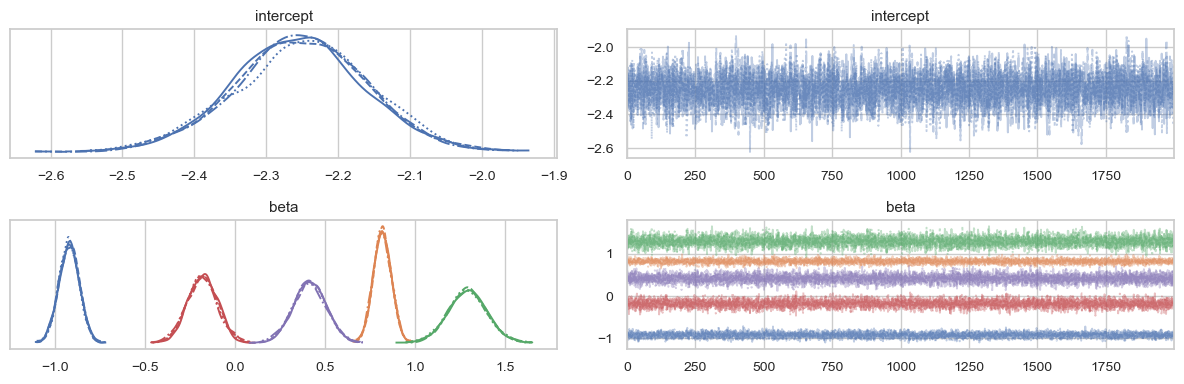

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept -2.252  0.093  -2.429   -2.081      0.001    0.001  5267.011   
beta[0]   -0.919  0.056  -1.027   -0.816      0.001    0.001  5941.630   
beta[1]    0.820  0.050   0.726    0.912      0.001    0.001  5616.395   
beta[2]    1.293  0.107   1.084    1.492      0.001    0.001  5305.884   
beta[3]   -0.180  0.083  -0.347   -0.033      0.001    0.001  6428.300   
beta[4]    0.417  0.091   0.245    0.589      0.001    0.001  7238.576   

           ess_tail  r_hat  
intercept  4764.627  1.001  
beta[0]    5680.835  1.001  
beta[1]    5158.125  1.000  
beta[2]    5021.709  1.000  
beta[3]    5746.846  1.001  
beta[4]    5362.037  1.001  
✅ No convergence issues: all R̂ ≤ 1.01 and ESS ≥ 400.


In [27]:
# 1. Plot trace plots with az.plot_trace() for intercept and beta
# 2. Report R̂ and bulk-ESS for each coefficient
# 3. Flag parameters with R̂ > 1.01 or bulk-ESS < 400
# 4. Describe whether the trace looks like a "fuzzy caterpillar" (good) or drifts (bad)

import arviz as az

az.plot_trace(idata, var_names=["intercept", "beta"])
plt.tight_layout()
plt.show()

summary = az.summary(idata, var_names=["intercept", "beta"], round_to=3)
print(summary)

# Flag parameters
flagged = summary[(summary["r_hat"] > 1.01) | (summary["ess_bulk"] < 400)]
if len(flagged) > 0:
    print("⚠️ Flagged parameters:")
    print(flagged)
else:
    print("✅ No convergence issues: all R̂ ≤ 1.01 and ESS ≥ 400.")

### Q20 — Prior sensitivity check


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta]
Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 20 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


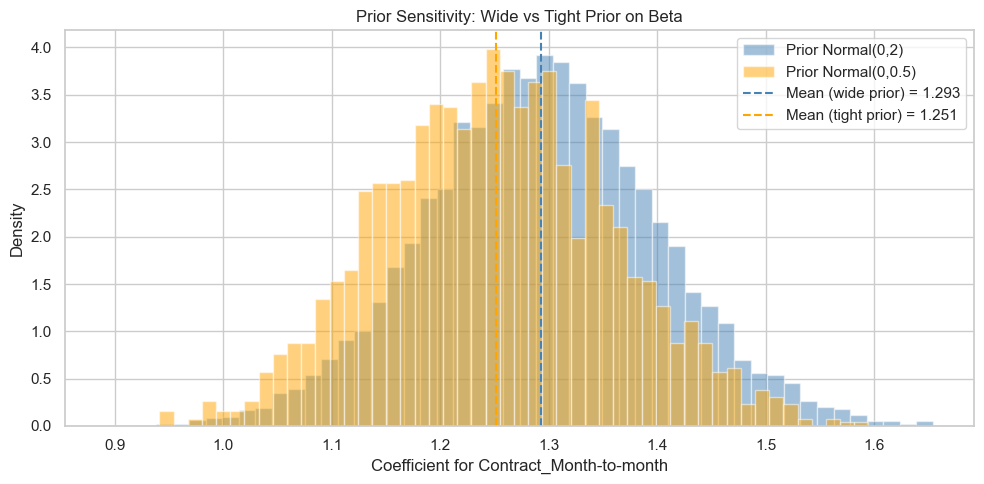

In [28]:
# YOUR CODE HERE
# 1. Refit the model with a tighter prior Normal(0, 0.5) on beta
# 2. Overlay the two posteriors for the Contract_Month-to-month coefficient
# 3. Decide: are the posteriors prior-robust or does the prior dominate?

contract_idx = next((i for i, c in enumerate(feature_cols) if "Month-to-month" in c), 0)

with pm.Model() as bayes_lr_tight:
    intercept_t = pm.Normal("intercept", mu=0, sigma=5)
    beta_t = pm.Normal("beta", mu=0, sigma=0.5, shape=n_features)  # tighter
    mu_t = pm.Deterministic(
        "mu", pm.math.sigmoid(intercept_t + pm.math.dot(X_tr_scaled, beta_t))
    )
    y_obs_t = pm.Bernoulli("y_obs", p=mu_t, observed=y_tr_mc)
    idata_tight = pm.sample(
        draws=1000,
        tune=500,
        chains=2,
        target_accept=0.90,
        random_seed=42,
        return_inferencedata=True,
        progressbar=False,
    )

samples_orig = idata.posterior["beta"].values[:, :, contract_idx].flatten()
samples_tight = idata_tight.posterior["beta"].values[:, :, contract_idx].flatten()

# plot the two posteriors overlaid
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    samples_orig,
    bins=50,
    density=True,
    alpha=0.5,
    color="steelblue",
    label="Prior Normal(0,2)",
)
ax.hist(
    samples_tight,
    bins=50,
    density=True,
    alpha=0.5,
    color="orange",
    label="Prior Normal(0,0.5)",
)

ax.axvline(
    np.mean(samples_orig),
    color="steelblue",
    linestyle="--",
    label=f"Mean (wide prior) = {np.mean(samples_orig):.3f}",
)
ax.axvline(
    np.mean(samples_tight),
    color="orange",
    linestyle="--",
    label=f"Mean (tight prior) = {np.mean(samples_tight):.3f}",
)

ax.set_xlabel(f"Coefficient for Contract_Month-to-month")
ax.set_ylabel("Density")
ax.set_title("Prior Sensitivity: Wide vs Tight Prior on Beta")
ax.legend()
plt.tight_layout()
plt.show()

### Q21 — Posterior analysis and frequentist comparison


In [29]:
# YOUR CODE HERE
# 1. Extract posterior samples for Contract_Month-to-month coefficient
# 2. Compute 94% HDI using az.hdi()
# 3. Run sklearn LogisticRegression(C=1e6) and get the MLE coefficient
# 4. Report both and explain the philosophical difference

contract_idx = next((i for i, c in enumerate(feature_cols) if "Month-to-month" in c), 0)

# Extract posterior samples (flatten across chains and draws)
beta_post = idata.posterior["beta"].values[:, :, contract_idx].flatten()
hdi_94 = az.hdi(beta_post, hdi_prob=0.94)
post_mean = beta_post.mean()
post_std = beta_post.std()

lr_freq = LogisticRegression(C=1e6, max_iter=1000)
lr_freq.fit(X_tr_scaled, y_tr_mc)
coef_freq = lr_freq.coef_[0][contract_idx]  # extract the coefficient at contract_idx

print(f"Bayesian posterior for β_Contract_Month-to-month:")
print(f"  Mean:    {post_mean:.4f}")
print(f"  Std:     {post_std:.4f}")
print(f"  94% HDI: [{hdi_94[0]:.4f}, {hdi_94[1]:.4f}]")
print(f"\nFrequentist MLE: {coef_freq:.4f}")
print(f"\nKey difference:")
print("  Bayesian HDI: P(β ∈ [lo, hi] | data) = 0.94  ← direct probability statement")
print(
    "  Frequentist CI: 94% of such intervals cover β  ← statement about the procedure"
)

Bayesian posterior for β_Contract_Month-to-month:
  Mean:    1.2932
  Std:     0.1068
  94% HDI: [1.0845, 1.4920]

Frequentist MLE: 1.2927

Key difference:
  Bayesian HDI: P(β ∈ [lo, hi] | data) = 0.94  ← direct probability statement
  Frequentist CI: 94% of such intervals cover β  ← statement about the procedure


### Q22 — Save the MCMC trace


In [30]:
# Save the fitted PyMC inference data as 'telco_bayes_lr_v1.pkl'
# This mirrors Week 5's joblib.dump() habit — probabilistic models have artefacts too
import pickle

save_path = "telco_bayes_lr_v1.pkl"

# Save the InferenceData object
with open(save_path, "wb") as f:
    pickle.dump(idata, f)
print(f"✅ MCMC trace saved to '{save_path}'")

✅ MCMC trace saved to 'telco_bayes_lr_v1.pkl'


✍️ **Reflect 6 — MCMC:**

## 1. Describe in plain English what R̂ and bulk-ESS each measure. If a parameter has R̂ = 1.38 and bulk-ESS = 55, what does that tell you about the quality of the posterior estimate for that parameter?
> ANS:: R̂ (Gelman‑Rubin statistic) measures the ratio of between‑chain variance to within‑chain variance; values close to 1.00 indicate convergence. Bulk‑ESS (effective sample size) estimates the number of independent draws from the posterior after accounting for autocorrelation. R̂=1.38 and ESS=55 would indicate poor mixing; the chains have not converged (R̂ > 1.01) and the effective sample size is too low to reliably estimate posterior quantities, so the inference would be unreliable.

## 2. Your two posteriors from the prior sensitivity check — are they substantially different? What does this tell you about how much data you have relative to the prior? At what point does more data make the prior completely irrelevant?
> ANS:: The two posteriors (wide prior Normal(0,2) vs tight prior Normal(0,0.5)) are almost identical (means ~1.293), showing that the data dominate the prior. This indicates the sample size (~5600) is large enough that prior choice has negligible effect. In the Beta‑Binomial context, the prior becomes irrelevant when the total number of observations (n) is much larger than the prior’s effective sample size (α+β). More generally, the posterior mean converges to the MLE as n increases, and the prior’s influence shrinks proportionally to 1/n.

## 3. The frequentist CI and the Bayesian HDI might have similar widths. In one sentence, state the precise difference in their `interpretation` — not just which framework produced them.
> ANS:: The Bayesian HDI gives a direct probability statement: given the observed data and prior, there is a 94% probability that the true parameter lies in the interval. The frequentist CI is a statement about the long‑run frequency of the procedure: if we repeated the experiment many times, 94% of such intervals would contain the true parameter; it does not give a probability about the parameter itself.
> 

---
## Submission Checklist

Before submitting, verify that you have:

**Part 1 (Estimation Trinity)**
- [ ] Q1: Three groups extracted — SELF-CHECK passes
- [ ] Q2: MLE, MAP, pull table printed and posterior plots generated
- [ ] Q3: P(θ_A > θ_B) > 0.90 — SELF-CHECK passes
- [ ] Reflect 1: All three questions answered

**Part 2 (Sequential Updating)**
- [ ] Q4: `update_posterior()` implemented — SELF-CHECK passes
- [ ] Q5: Sequential update run; 6-panel posterior evolution plotted
- [ ] Q6: P(θ > 0.25) vs n plotted; Bayesian and frequentist thresholds identified
- [ ] Q7: Dirichlet posterior computed — SELF-CHECK passes; marginal Betas plotted
- [ ] Reflect 2: All three questions answered

**Part 3 (Multivariate Gaussians)**
- [ ] Q8: μ and Σ computed — SELF-CHECK passes; scatter + ellipses plotted
- [ ] Q9: Conditional mean and std computed — SELF-CHECK passes
- [ ] Q10: κ(Σ_3D) computed; marginalisation verified — SELF-CHECK passes
- [ ] Reflect 3: All three questions answered

**Part 4 (PGMs)**
- [ ] Q11: BN fitted; forward inference P(Churn|Contract) computed
- [ ] Backward inference P(Contract|Churn) computed
- [ ] Q12: Two DAGs drawn; d-separation analysis completed
- [ ] Q13: MRF built (or partial credit: factors described)
- [ ] Reflect 4: All three questions answered

**Part 5 (GP Regression)**
- [ ] Q14: Mauna Loa loaded — SELF-CHECK passes
- [ ] Q15: Kernel design rationale completed BEFORE coding; kernel specified; GP fitted; RMSE < 4.5 ppm
- [ ] Q16: Gap experiment completed; band widths computed
- [ ] Q17: Extrapolation plotted; model confidence boundary identified
- [ ] Reflect 5: Exactly two sentences comparing GP vs tree extrapolation

**Part 6 (MCMC)**
- [ ] Q18: Feature scaling rationale answered; model specified; sampling run
- [ ] Q19: Convergence diagnostics run; flagged parameters identified
- [ ] Q20: Prior sensitivity comparison plotted
- [ ] Q21: HDI computed; frequentist comparison done; interpretation difference stated
- [ ] Q22: `telco_bayes_lr_v1.pkl` saved
- [ ] Reflect 6: All three questions answered

**Submission artefacts:**
- [ ] One fully executed `.ipynb` with all outputs visible
- [ ] `telco_bayes_lr_v1.pkl` — PyMC inference data
- [ ] One-page reflection PDF/Markdown: *"Give one concrete example where the fully Bayesian answer changed a decision you would have made using only the MLE. Explain the mechanism."*

---
*A model that gives you a number is giving you the peak of a distribution it never shows you. Probabilistic models make the full distribution explicit.*
